In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv')

In [3]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [4]:
df.shape

(7500, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [6]:
df.columns

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

In [7]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [8]:
df.isnull().sum()

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

In [9]:
df['addiction_level'].fillna(df['addiction_level'].mode()[0],inplace=True)

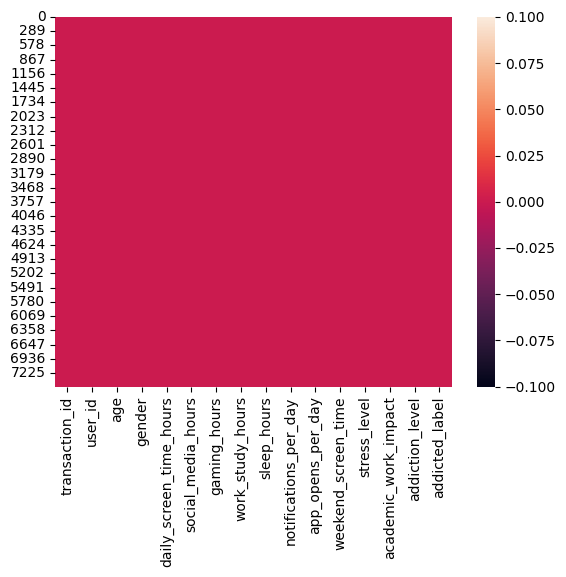

In [10]:
sns.heatmap(df.isnull());

In [11]:
df.duplicated().sum()

np.int64(0)

gender
Male      2553
Other     2486
Female    2461
Name: count, dtype: int64


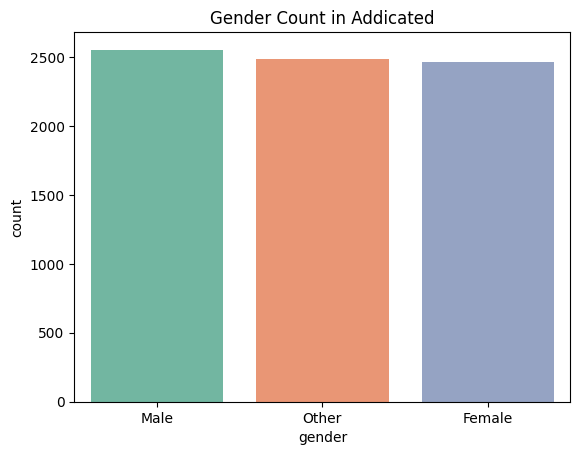

In [12]:
print(df['gender'].value_counts())
sns.countplot(x='gender', data=df, palette='Set2')
plt.title("Gender Count in Addicated")
plt.show()

addiction_level
Moderate    3693
Severe      2434
Mild        1373
Name: count, dtype: int64


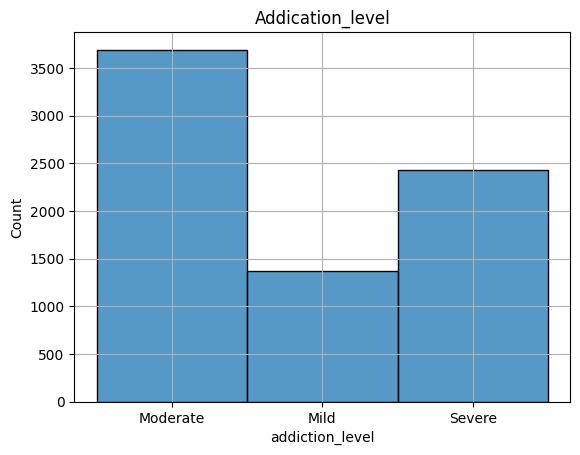

In [13]:
print(df['addiction_level'].value_counts())
sns.histplot(x='addiction_level', data=df)
plt.title("Addication_level")
plt.grid()
plt.show()

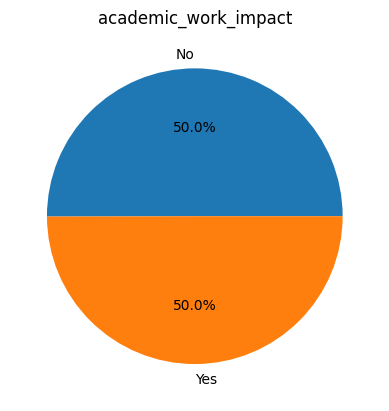

In [14]:
on=df['academic_work_impact'].value_counts().head(5)
plt.pie(on, labels=on.index, autopct='%1.1f%%')
plt.title('academic_work_impact')
plt.show()

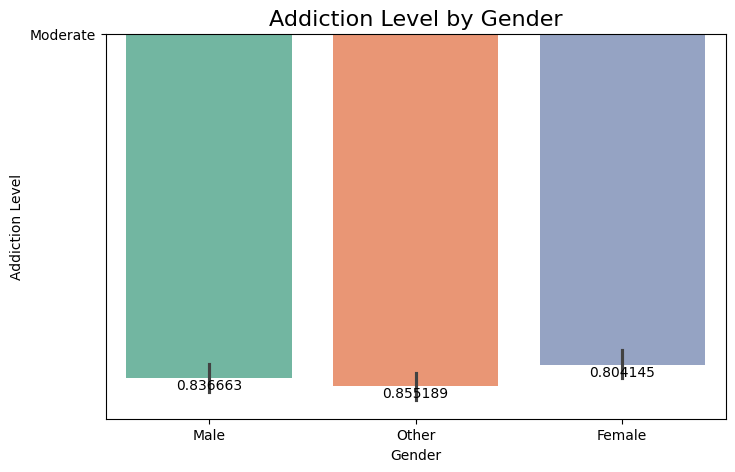

In [15]:


plt.figure(figsize=(8,5))

ax = sns.barplot(x='gender', y='addiction_level', data=df, palette='Set2')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Addiction Level by Gender", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Addiction Level")

plt.show()

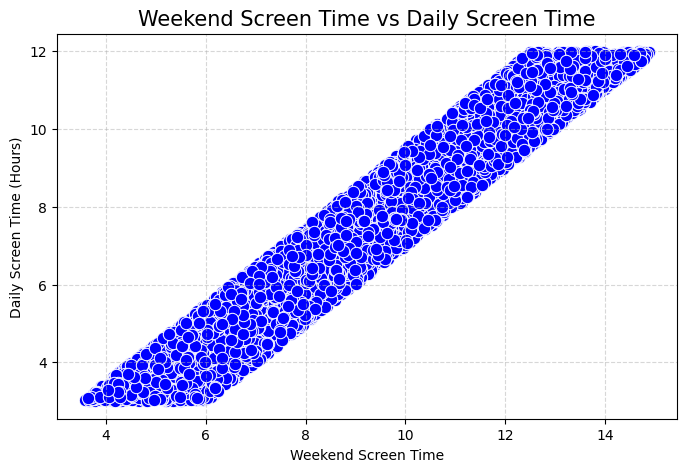

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='weekend_screen_time',
    y='daily_screen_time_hours',
    data=df,
    color='blue',
    s=80
)

plt.title("Weekend Screen Time vs Daily Screen Time", fontsize=15)
plt.xlabel("Weekend Screen Time")
plt.ylabel("Daily Screen Time (Hours)")

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [17]:
df['addicted_label'].value_counts()

addicted_label
1    5308
0    2192
Name: count, dtype: int64

In [18]:
num_cols=df.select_dtypes(include=['int64','float64'])
cat_cols=df.select_dtypes(include=['object'])

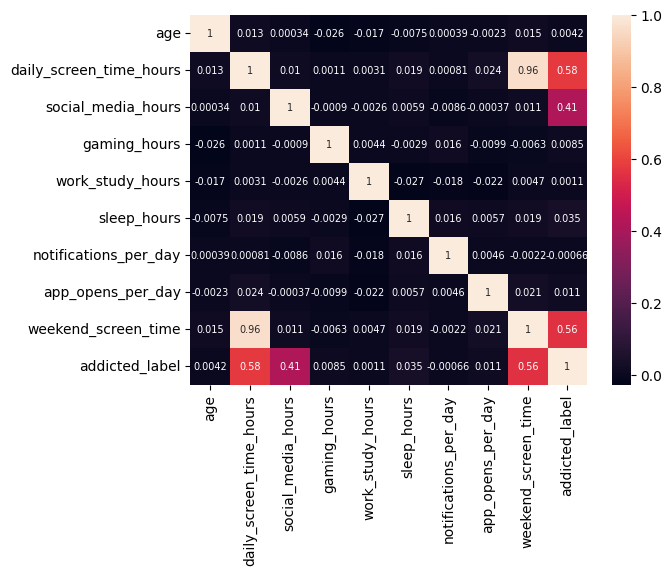

In [19]:
sns.heatmap(num_cols.corr(),annot=True,annot_kws={'size':7});

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [21]:
x1=df.drop(['transaction_id','user_id'],axis=1)

In [22]:
num_cols_01= x1.select_dtypes(include=['int64','float64']).columns[:-1]
cat_cols_01= x1.select_dtypes(include=['object']).columns
x=x1.iloc[:,:-1]
y=df['addicted_label']

In [23]:
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

In [24]:
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])

In [25]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols_01),
    ("cat", cat_pipeline, cat_cols_01)
])

In [26]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [28]:
models = {
    "Logistic Regression": LogisticRegression(),
    "knn": KNeighborsClassifier(),
    "svc": SVC(C=10, gamma='auto', kernel='rbf', probability=True)
}

results = {}
trained_models = {}   

for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipeline.fit(x_train, y_train)
    
    y_pred = pipeline.predict(x_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    train_score = pipeline.score(x_train, y_train)

    results[name] = accuracy
    trained_models[name] = pipeline   # store trained model
    
    print("Model:", name)
    print("train_score:", train_score)
    print("test_score:", accuracy)

Model: Logistic Regression
train_score: 0.968
test_score: 0.9753333333333334
Model: knn
train_score: 0.9763333333333334
test_score: 0.9586666666666667
Model: svc
train_score: 0.9941666666666666
test_score: 0.98


In [29]:
svc_model = trained_models['svc']
from sklearn.metrics import classification_report, confusion_matrix

y_pred = svc_model.predict(x_test)

cmx=confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))
print(cmx)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       456
           1       0.99      0.99      0.99      1044

    accuracy                           0.98      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500

[[ 441   15]
 [  15 1029]]


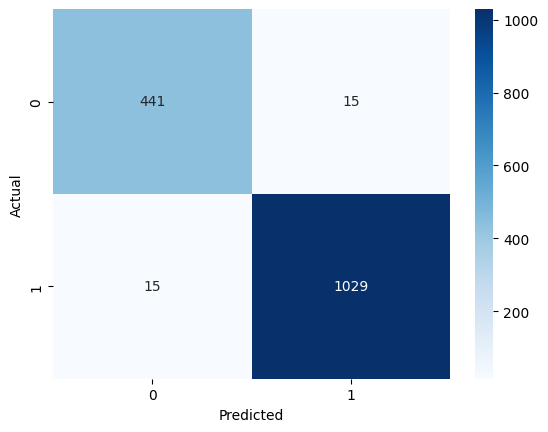

In [30]:
sns.heatmap(cmx, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
from sklearn.model_selection import cross_val_score,GridSearchCV

scores = cross_val_score(svc_model, x, y, cv=5)

print("Cross Validation Score:", scores.mean())

Cross Validation Score: 0.9817333333333333


In [32]:
param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__kernel': ['linear', 'rbf', 'poly'],
    'model__gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    svc_model,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
Best Score: 0.9824999999999999


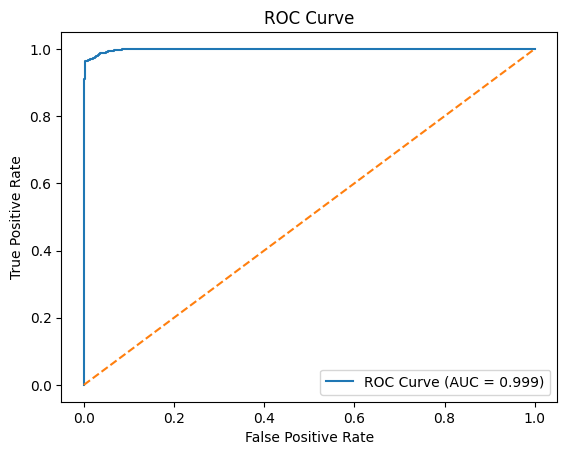

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = svc_model.predict_proba(x_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

# plot
plt.plot(fpr, tpr, label="ROC Curve (AUC = %.3f)" % auc_score)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [34]:
import pickle

pickle.dump(svc_model, open("addiction_model.pkl","wb"))

In [35]:
def predict_addiction(data):
    model = pickle.load(open("addiction_model.pkl","rb"))
    prediction = model.predict(data)
    return prediction